In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

In [2]:
#create a sample array of 8X8 -64pixels-#
image_array=np.arange(150*150).reshape(150,150)
#replace zero value with some other number for clarity#
image_array[image_array==0]=1
print(np.size(image_array))

22500


In [3]:
#spherical coordinates#
theta = np.linspace(0, np.pi, num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.pi, np.pi, num=image_array.shape[1],endpoint=False)



In [8]:
nside=30
print(hp.nside2npix(nside)) #clearly underfitting the healpix map#

10800


In [9]:
healpix_map=np.zeros(hp.nside2npix(nside),dtype=np.double)
pixel_counts=np.zeros(hp.nside2npix(nside),dtype=int)
print(np.shape(healpix_map))

(10800,)


10800


<IPython.core.display.Javascript object>


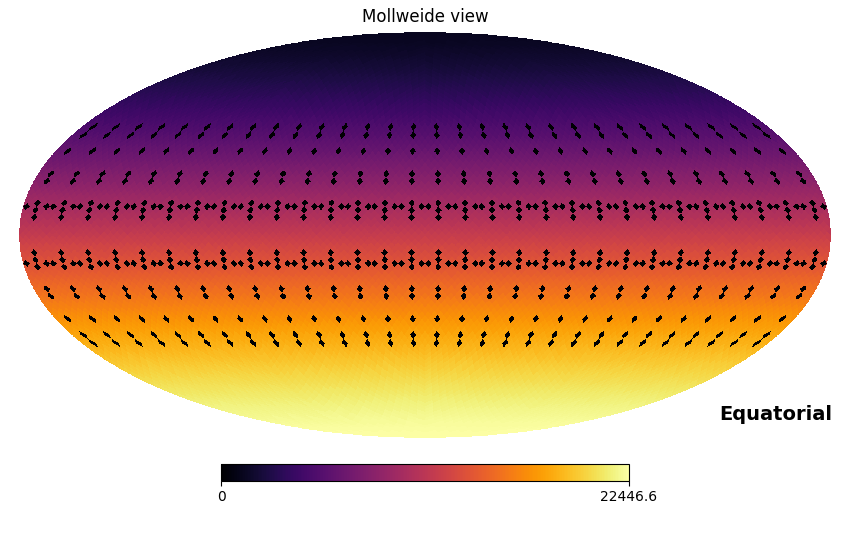

In [10]:
pix=[]
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1
        pix.append(pixel)

# Average and assign to HEALPix#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]
print(np.size(healpix_map))
%matplotlib notebook
hp.mollview(healpix_map, cmap="inferno", xsize=3000,coord="c", flip="geo", norm="hist",nest=False)
plt.show()


In [7]:
print(pix)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 2, 2, 2, 2, 2, 2, 2, 2, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 

In [12]:
import numpy as np
import healpy as hp
import pandas as pd

In [13]:
dff=pd.read_csv('./database/USA.csv')
lon=dff['Longitude in degrees'].to_numpy()
lat=dff['Latitude in degrees'].to_numpy()


In [14]:
pix=hp.ang2pix(128,lon,lat,lonlat=True)

In [15]:
select_pix=np.random.choice(pix,size=5000)

In [16]:
new_lon,new_lat=hp.pix2ang(128,select_pix,lonlat=True)
new_lon[new_lon>180]-=360
newdf=pd.DataFrame({'Lon':new_lon,'Lat':new_lat})
newdf.to_csv('./usaTrain.csv')

In [24]:
# using asterisk
def addition(args):
    return (args)

print(addition(5, 10, 20, 6))


TypeError: addition() takes 1 positional argument but 4 were given